## Setup

In [ ]:
import re
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

# Estilo acadêmico
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({
    'font.size': 10,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'lines.linewidth': 1.5,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'legend.fontsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

ROOT = Path('.').resolve()
TESTCASE = 't06-ecn-sender-ect1-prague-dualpi2-ecn2'
CLIENT_LOG = ROOT / 'experiments' / TESTCASE / 'esp_client.log'
SERVER_LOG = ROOT / 'experiments' / TESTCASE / 'server.log'
OUTPUT_DIR = ROOT / 'experiments' / TESTCASE

# Criar diretório de saída se não existir
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Working directory: {ROOT}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Client log: {CLIENT_LOG.exists()}")
print(f"Server log: {SERVER_LOG.exists()}")

Working directory: /Users/juscelioreis/Documents/code/master-l4s-iot/esp32-udp-prague
Output directory: /Users/juscelioreis/Documents/code/master-l4s-iot/esp32-udp-prague/experiments/t06-ecn-sender-ect1-prague-dualpi2-ecn2
Client log: True
Server log: True


## Parsing Cliente

In [62]:
def load_client_log(path=CLIENT_LOG):
    """Parse CSTATS format: CSTATS;t_ms;packets_sent;packets_received;inflight;rtt_us;jitter_us;packet_window;packet_burst;pacing_rate_bps
    Note: RTT and Jitter are in microseconds (us), converted to milliseconds (ms)"""
    rows = []
    with open(path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line.startswith('CSTATS;'):
                continue
            parts = line.split(';')
            if len(parts) != 10:
                continue
            try:
                rows.append({
                    't_ms': int(parts[1]),
                    'packets_sent': int(parts[2]),
                    'packets_received': int(parts[3]),
                    'inflight': int(parts[4]),
                    'rtt_ms': float(parts[5]) / 1000.0,  # Convert microseconds to milliseconds
                    'jitter_ms': float(parts[6]) / 1000.0,  # Convert microseconds to milliseconds
                    'packet_window': int(parts[7]),
                    'packet_burst': int(parts[8]),
                    'pacing_rate_bps': float(parts[9]),
                })
            except (ValueError, IndexError):
                continue
    
    df = pd.DataFrame(rows)
    if not df.empty:
        df['t_client_s'] = df['t_ms'] / 1000.0
        df = df.sort_values('t_client_s').reset_index(drop=True)
        print(f"\n✓ Cliente: {len(df)} amostras")
        print(f"  Tempo: [{df['t_client_s'].min():.3f}, {df['t_client_s'].max():.3f}] s")
        print(f"  Pacotes enviados: {df['packets_sent'].iloc[-1]} (total)")
        print(f"  RTT: {df['rtt_ms'].mean():.2f} ± {df['rtt_ms'].std():.2f} ms")
        print(f"  Jitter: {df['jitter_ms'].mean():.2f} ± {df['jitter_ms'].std():.2f} ms")
        print(f"  Pacing: {df['pacing_rate_bps'].mean()/1e6:.2f} ± {df['pacing_rate_bps'].std()/1e6:.2f} Mbps")
    return df

try:
    df_client = load_client_log()
    display(df_client.head())
except FileNotFoundError:
    print(f"✗ Cliente não encontrado: {CLIENT_LOG}")
    df_client = pd.DataFrame()


✓ Cliente: 37486 amostras
  Tempo: [0.141, 599.999] s
  Pacotes enviados: 37980 (total)
  RTT: 203.31 ± 10.62 ms
  Jitter: 4.43 ± 6.47 ms
  Pacing: 1.28 ± 0.48 Mbps


,t_ms,packets_sent,packets_received,inflight,rtt_ms,jitter_ms,packet_window,packet_burst,pacing_rate_bps,t_client_s
0,141,11,1,10,140.732,0.000,3,1,13820.0,0.141
1,151,11,2,9,128.787,11.945,3,1,19256.0,0.151
2,159,11,3,8,133.823,5.036,3,1,24665.0,0.159
3,171,11,4,7,132.887,0.936,3,1,29396.0,0.171
4,175,11,5,6,124.185,8.702,4,1,33703.0,0.175


## Parsing Servidor

In [63]:
# Regex para parsing do formato RECVER com bytes/s
# Formato RTT: N/A não tem "ms", formato com valor numérico tem "ms"
# Exemplo: [RECVER]: 8.09 sec, Rcvd: 1396000 B/s, Sent: 26000 B/s, RTT: N/A, Mark: 0.00%(0/1), Lost: 0.00%(0/1)
server_re = re.compile(
    r'\[RECVER\]:\s+'
    r'(?P<time_sec>[\d.]+)\s+sec,\s+'
    r'Rcvd:\s+(?P<rcvd>[\d.]+)\s+B/s,\s+'
    r'Sent:\s+(?P<sent>[\d.]+)\s+B/s,\s+'
    r'(?:RTT:\s+(?P<rtt>N/A|[\d.]+\s+ms)|ATO:\s+(?P<ato>[\d.]+)\s+ms),\s+'
    r'Mark:\s+(?P<mark_pct>[\d.]+)%\((?P<ce>\d+)/(?P<mark_total>\d+)\),\s+'
    r'Lost:\s+(?P<lost_pct>[\d.]+)%\((?P<lost>\d+)/(?P<lost_total>\d+)\)'
)

def load_server_log(path=SERVER_LOG):
    """Parse RECVER format - 200ms buckets (non-overlapping)"""
    rows = []
    with open(path, 'r') as f:
        for line in f:
            line = line.strip()
            m = server_re.match(line)
            if not m:
                continue
            g = m.groupdict()
            try:
                rows.append({
                    'time_sec': float(g['time_sec']),
                    'rcvd_rate_bytes_s': float(g['rcvd']),
                    'sent_rate_bytes_s': float(g['sent']),
                    'ce_rate_percent': float(g['mark_pct']),
                    'ce_count': int(g['ce']),
                    'ce_total': int(g['mark_total']),
                    'loss_rate_percent': float(g['lost_pct']),
                    'loss_count': int(g['lost']),
                    'loss_total': int(g['lost_total']),
                })
            except (ValueError, KeyError):
                continue
    
    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values('time_sec').reset_index(drop=True)
        
        # Clamp loss_rate_percent to valid range [0, 100] due to server counter artifacts
        df['loss_rate_percent'] = df['loss_rate_percent'].clip(0, 100)
        
        print(f"\n✓ Servidor: {len(df)} amostras (200ms buckets)")
        print(f"  Tempo: [{df['time_sec'].min():.3f}, {df['time_sec'].max():.3f}] s")
        print(f"  RX throughput: {df['rcvd_rate_bytes_s'].mean():.0f} ± {df['rcvd_rate_bytes_s'].std():.0f} B/s")
        print(f"  CE-mark rate: {df['ce_rate_percent'].mean():.2f} ± {df['ce_rate_percent'].std():.2f} %")
        print(f"  Loss rate: {df['loss_rate_percent'].mean():.4f} ± {df['loss_rate_percent'].std():.4f} %")
    return df

try:
    df_server = load_server_log()
    display(df_server.head())
except FileNotFoundError:
    print(f"✗ Servidor não encontrado: {SERVER_LOG}")
    df_server = pd.DataFrame()

""


## Metadados do Teste

In [64]:
def extract_metadata(path=CLIENT_LOG):
    """Extract test metadata from client log header"""
    meta = {}
    try:
        with open(path, 'r') as f:
            for line in f:
                line = line.strip()
                if line.startswith('IoT Node ID:'):
                    meta['IoT Node ID'] = line.split(':', 1)[1].strip()
                elif line.startswith('Test Scenario:'):
                    meta['Test Scenario'] = line.split(':', 1)[1].strip()
                elif line.startswith('Payload Size:'):
                    meta['Payload Size'] = line.split(':', 1)[1].strip()
                elif line.startswith('Initial Burst Limit:'):
                    meta['Initial Burst Limit'] = line.split(':', 1)[1].strip()
                elif line.startswith('Duration:'):
                    meta['Duration'] = line.split(':', 1)[1].strip()
                elif line.startswith('ECN'):
                    meta['ECN'] = line.split(':', 1)[1].strip()
                elif line.startswith('Gateway CC Algorithm:'):
                    meta['Gateway CC Algorithm'] = line.split(':', 1)[1].strip()
                elif line.startswith('Gateway Qdisc:'):
                    meta['Gateway Qdisc'] = line.split(':', 1)[1].strip()
    except FileNotFoundError:
        pass
    return meta

metadata = extract_metadata()
print("\n📋 Test Metadata:")
for k, v in metadata.items():
    print(f"  {k}: {v}")


📋 Test Metadata:
  IoT Node ID: 1
  Test Scenario: High Load
  ECN: 1
  Payload Size: 1396 bytes (header: 13 + extra: 1383)
  Initial Burst Limit: 3 packets
  Duration: 600 seconds
  Gateway CC Algorithm: prague
  Gateway Qdisc: dualpi2


## Compute Goodput (RX / Pacing)

In [65]:
# Prepare goodput metric (cliente only)
if not df_client.empty:
    # Convert pacing_rate_bps to Mbps for goodput calculation
    df_client['pacing_rate_mbps'] = df_client['pacing_rate_bps'] / 1e6
    
    # Goodput = RX / Pacing (both in Mbps)
    # But we don't have RX from client directly, so goodput will be estimated differently
    # For now, mark it as NA
    print(f"✓ Cliente prepared: {len(df_client)} rows")
else:
    print("✗ Client data unavailable")

✓ Cliente prepared: 37486 rows


## 📊 Análise de Transmissão (Cliente ↔ Servidor)

In [66]:
# Análise Comparativa: Cliente (TX) vs Servidor (RX)
if not df_client.empty and not df_server.empty:
    # === PACOTES ===
    # Cliente: total de pacotes enviados (acumulativo)
    client_packets_sent = df_client['packets_sent'].iloc[-1]
    
    # Servidor: total de pacotes recebidos
    # Usar ce_total que é o acumulativo (não ce_count que é incremento por bucket)
    server_packets_received = df_server['ce_total'].sum()
    
    # Pacotes com CE-mark
    server_packets_marked = df_server['ce_count'].sum()
    
    # Pacotes perdidos
    packets_lost_total = client_packets_sent - server_packets_received
    packets_loss_rate = (packets_lost_total / client_packets_sent * 100) if client_packets_sent > 0 else 0
    
    # === BYTES ===
    # Extrair tamanho do pacote dos metadados
    # Formato: "Payload Size: 1396 bytes (header: 13 + extra: 1383)"
    PACKET_SIZE_BYTES = 1396  # Valor padrão
    if 'Payload Size' in metadata:
        payload_str = metadata['Payload Size']
        # Extrair primeiro número (tamanho total em bytes)
        match = re.search(r'(\d+)\s*bytes', payload_str)
        if match:
            PACKET_SIZE_BYTES = int(match.group(1))
    
    client_bytes_sent = client_packets_sent * PACKET_SIZE_BYTES
    
    # Servidor: calcular bytes recebidos a partir dos pacotes recebidos (mais preciso)
    # Usar a contagem de pacotes vezes o tamanho do pacote
    server_bytes_received = server_packets_received * PACKET_SIZE_BYTES
    
    bytes_lost = client_bytes_sent - server_bytes_received
    bytes_loss_rate = (bytes_lost / client_bytes_sent * 100) if client_bytes_sent > 0 else 0
    
    # === RELATÓRIO ===
    print("="*60)
    print("📦 ANÁLISE DE TRANSMISSÃO: Cliente → Servidor")
    print("="*60)
    print(f"\n{'Métrica':<40} {'Cliente (TX)':<15} {'Servidor (RX)':<15} {'Perda':<15}")
    print("-"*60)
    print(f"{'Pacotes':<40} {client_packets_sent:<15,} {server_packets_received:<15,} {packets_lost_total:<15,}")
    print(f"{'Taxa de perda de pacotes':<40} {'':<15} {'':<15} {packets_loss_rate:>14.2f}%")
    print(f"{'Bytes ({PACKET_SIZE_BYTES} bytes/pkt)':<40} {client_bytes_sent:<15,} {int(server_bytes_received):<15,} {int(bytes_lost):<15,}")
    print(f"{'Taxa de perda de bytes':<40} {'':<15} {'':<15} {bytes_loss_rate:>14.2f}%")
    print("-"*60)
    print(f"\nℹ️  Pacotes com CE-mark: {server_packets_marked:,}")
    print(f"ℹ️  Taxa de marcação ECN: {(server_packets_marked / server_packets_received * 100) if server_packets_received > 0 else 0:.2f}%")
    
    # Armazenar no summary
    transmission_stats = {
        'packet_size_bytes': PACKET_SIZE_BYTES,
        'client_packets_sent': client_packets_sent,
        'server_packets_received': server_packets_received,
        'server_packets_marked': server_packets_marked,
        'packets_lost': packets_lost_total,
        'packet_loss_rate_percent': packets_loss_rate,
        'ecn_mark_rate_percent': (server_packets_marked / server_packets_received * 100) if server_packets_received > 0 else 0,
        'client_bytes_sent_est': client_bytes_sent,
        'server_bytes_received_est': int(server_bytes_received),
        'bytes_lost_est': int(bytes_lost),
        'byte_loss_rate_percent': bytes_loss_rate,
    }
else:
    print("⚠️  Dados insuficientes para análise de transmissão")
    transmission_stats = {}


⚠️  Dados insuficientes para análise de transmissão


In [67]:

# Gráfico de Transmissão: Cliente → Servidor
if not df_client.empty and not df_server.empty and transmission_stats:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Transmission Analysis: Client → Server', fontsize=13, fontweight='bold')
    
    # (H) Packets: Sent vs Received
    ax = axes[0]
    categories = ['Sent', 'Received', 'Lost']
    values = [
        transmission_stats['client_packets_sent'],
        transmission_stats['server_packets_received'],
        transmission_stats['packets_lost']
    ]
    colors = ['#06A77D', '#1E88E5', '#D32F2F']
    
    bars = ax.bar(categories, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(val):,}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_ylabel('Packets', fontsize=10)
    ax.set_title('(H) Packet Loss Analysis', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    
    # (I) Bytes: Sent vs Received
    ax = axes[1]
    categories = ['Sent', 'Received', 'Lost']
    bytes_values = [
        transmission_stats['client_bytes_sent_est'],
        transmission_stats['server_bytes_received_est'],
        transmission_stats['bytes_lost_est']
    ]
    
    bars = ax.bar(categories, bytes_values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    
    # Add value labels on bars (in bytes)
    for bar, val in zip(bars, bytes_values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(val):,}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_ylabel('Bytes', fontsize=10)
    ax.set_title('(I) Byte Loss Analysis', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    
    # Save the transmission plot
    fname = OUTPUT_DIR / f"{base_name}_transmission_analysis.png"
    fig.savefig(fname, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {fname}")
    plt.show()


## Plotting Functions

In [68]:
def plot_client_metrics(df_client, metadata):
    """Plot RTT, Jitter, Inflight, Pacing Rate"""
    if df_client.empty:
        print("No client data to plot")
        return
    
    fig, axes = plt.subplots(4, 1, figsize=(12, 10))
    fig.suptitle('Client Metrics (ESP32 - UDP-Prague)', fontsize=13, fontweight='bold')
    
    # (A) RTT
    ax = axes[0]
    ax.plot(df_client['t_client_s'], df_client['rtt_ms'], color='#2E86AB', linewidth=1.5, label='RTT')
    ax.set_ylabel('RTT (ms)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_title('(A) Round Trip Time', fontsize=10)
    
    # (B) Jitter
    ax = axes[1]
    ax.plot(df_client['t_client_s'], df_client['jitter_ms'], color='#A23B72', linewidth=1.5, label='Jitter')
    ax.set_ylabel('Jitter (ms)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_title('(B) Jitter (Stability)', fontsize=10)
    
    # (C) Inflight
    ax = axes[2]
    ax.plot(df_client['t_client_s'], df_client['inflight'], color='#F18F01', linewidth=1.5, label='Inflight')
    ax.set_ylabel('Inflight (packets)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_title('(C) In-Flight Packets (CC Behavior)', fontsize=10)
    
    # (D) Pacing Rate
    ax = axes[3]
    ax.plot(df_client['t_client_s'], df_client['pacing_rate_mbps'], color='#06A77D', linewidth=1.5, label='Pacing Rate')
    ax.set_ylabel('Pacing Rate (Mbps)', fontsize=10)
    ax.set_xlabel('Time (s)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_title('(D) Pacing Rate (Adaptation)', fontsize=10)
    
    plt.tight_layout()
    return fig

def plot_server_metrics(df_server, metadata):
    """Plot RX Throughput, CE-mark Rate, Loss Rate"""
    if df_server.empty:
        print("No server data to plot")
        return
    
    fig, axes = plt.subplots(3, 1, figsize=(12, 9))
    fig.suptitle('Server Metrics (DualPI2 Gateway)', fontsize=13, fontweight='bold')
    
    # (E) RX Throughput
    ax = axes[0]
    ax.plot(df_server['time_sec'], df_server['rcvd_rate_bytes_s'], color='#1E88E5', linewidth=1.5, label='RX Throughput')
    ax.set_ylabel('Throughput (bytes/s)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_title('(E) Received Throughput', fontsize=10)
    
    # (F) CE-mark Rate
    ax = axes[1]
    ax.plot(df_server['time_sec'], df_server['ce_rate_percent'], color='#D32F2F', linewidth=1.5, label='CE-mark Rate')
    ax.set_ylabel('CE-mark Rate (%)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_title('(F) CE-Mark Rate (L4S Signal)', fontsize=10)
    
    # (G) Loss Rate
    ax = axes[2]
    ax.plot(df_server['time_sec'], df_server['loss_rate_percent'], color='#FF6F00', linewidth=1.5, label='Loss Rate')
    ax.set_ylabel('Loss Rate (%)', fontsize=10)
    ax.set_xlabel('Time (s)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_title('(G) Packet Loss', fontsize=10)
    
    plt.tight_layout()
    return fig

def plot_cdf_rtt(df_client):
    """Plot CDF of RTT"""
    if df_client.empty:
        return
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    rtt_sorted = np.sort(df_client['rtt_ms'].dropna())
    cdf = np.arange(1, len(rtt_sorted) + 1) / len(rtt_sorted)
    
    ax.plot(rtt_sorted, cdf * 100, color='#2E86AB', linewidth=2, label='RTT CDF')
    ax.set_xlabel('RTT (ms)', fontsize=11)
    ax.set_ylabel('Probability (%)', fontsize=11)
    ax.set_title('(I) CDF of RTT (Client)', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
    
    plt.tight_layout()
    return fig

print("✓ Plotting functions defined")

✓ Plotting functions defined


## Generate and Save Plots

Output name: prague_academic_high_load_node1_ccprague_qdiscdualpi2_ecn1
✓ Saved: /Users/juscelioreis/Documents/code/master-l4s-iot/esp32-udp-prague/experiments/t06-ecn-sender-ect1-prague-dualpi2-ecn2/prague_academic_high_load_node1_ccprague_qdiscdualpi2_ecn1_client_metrics.png


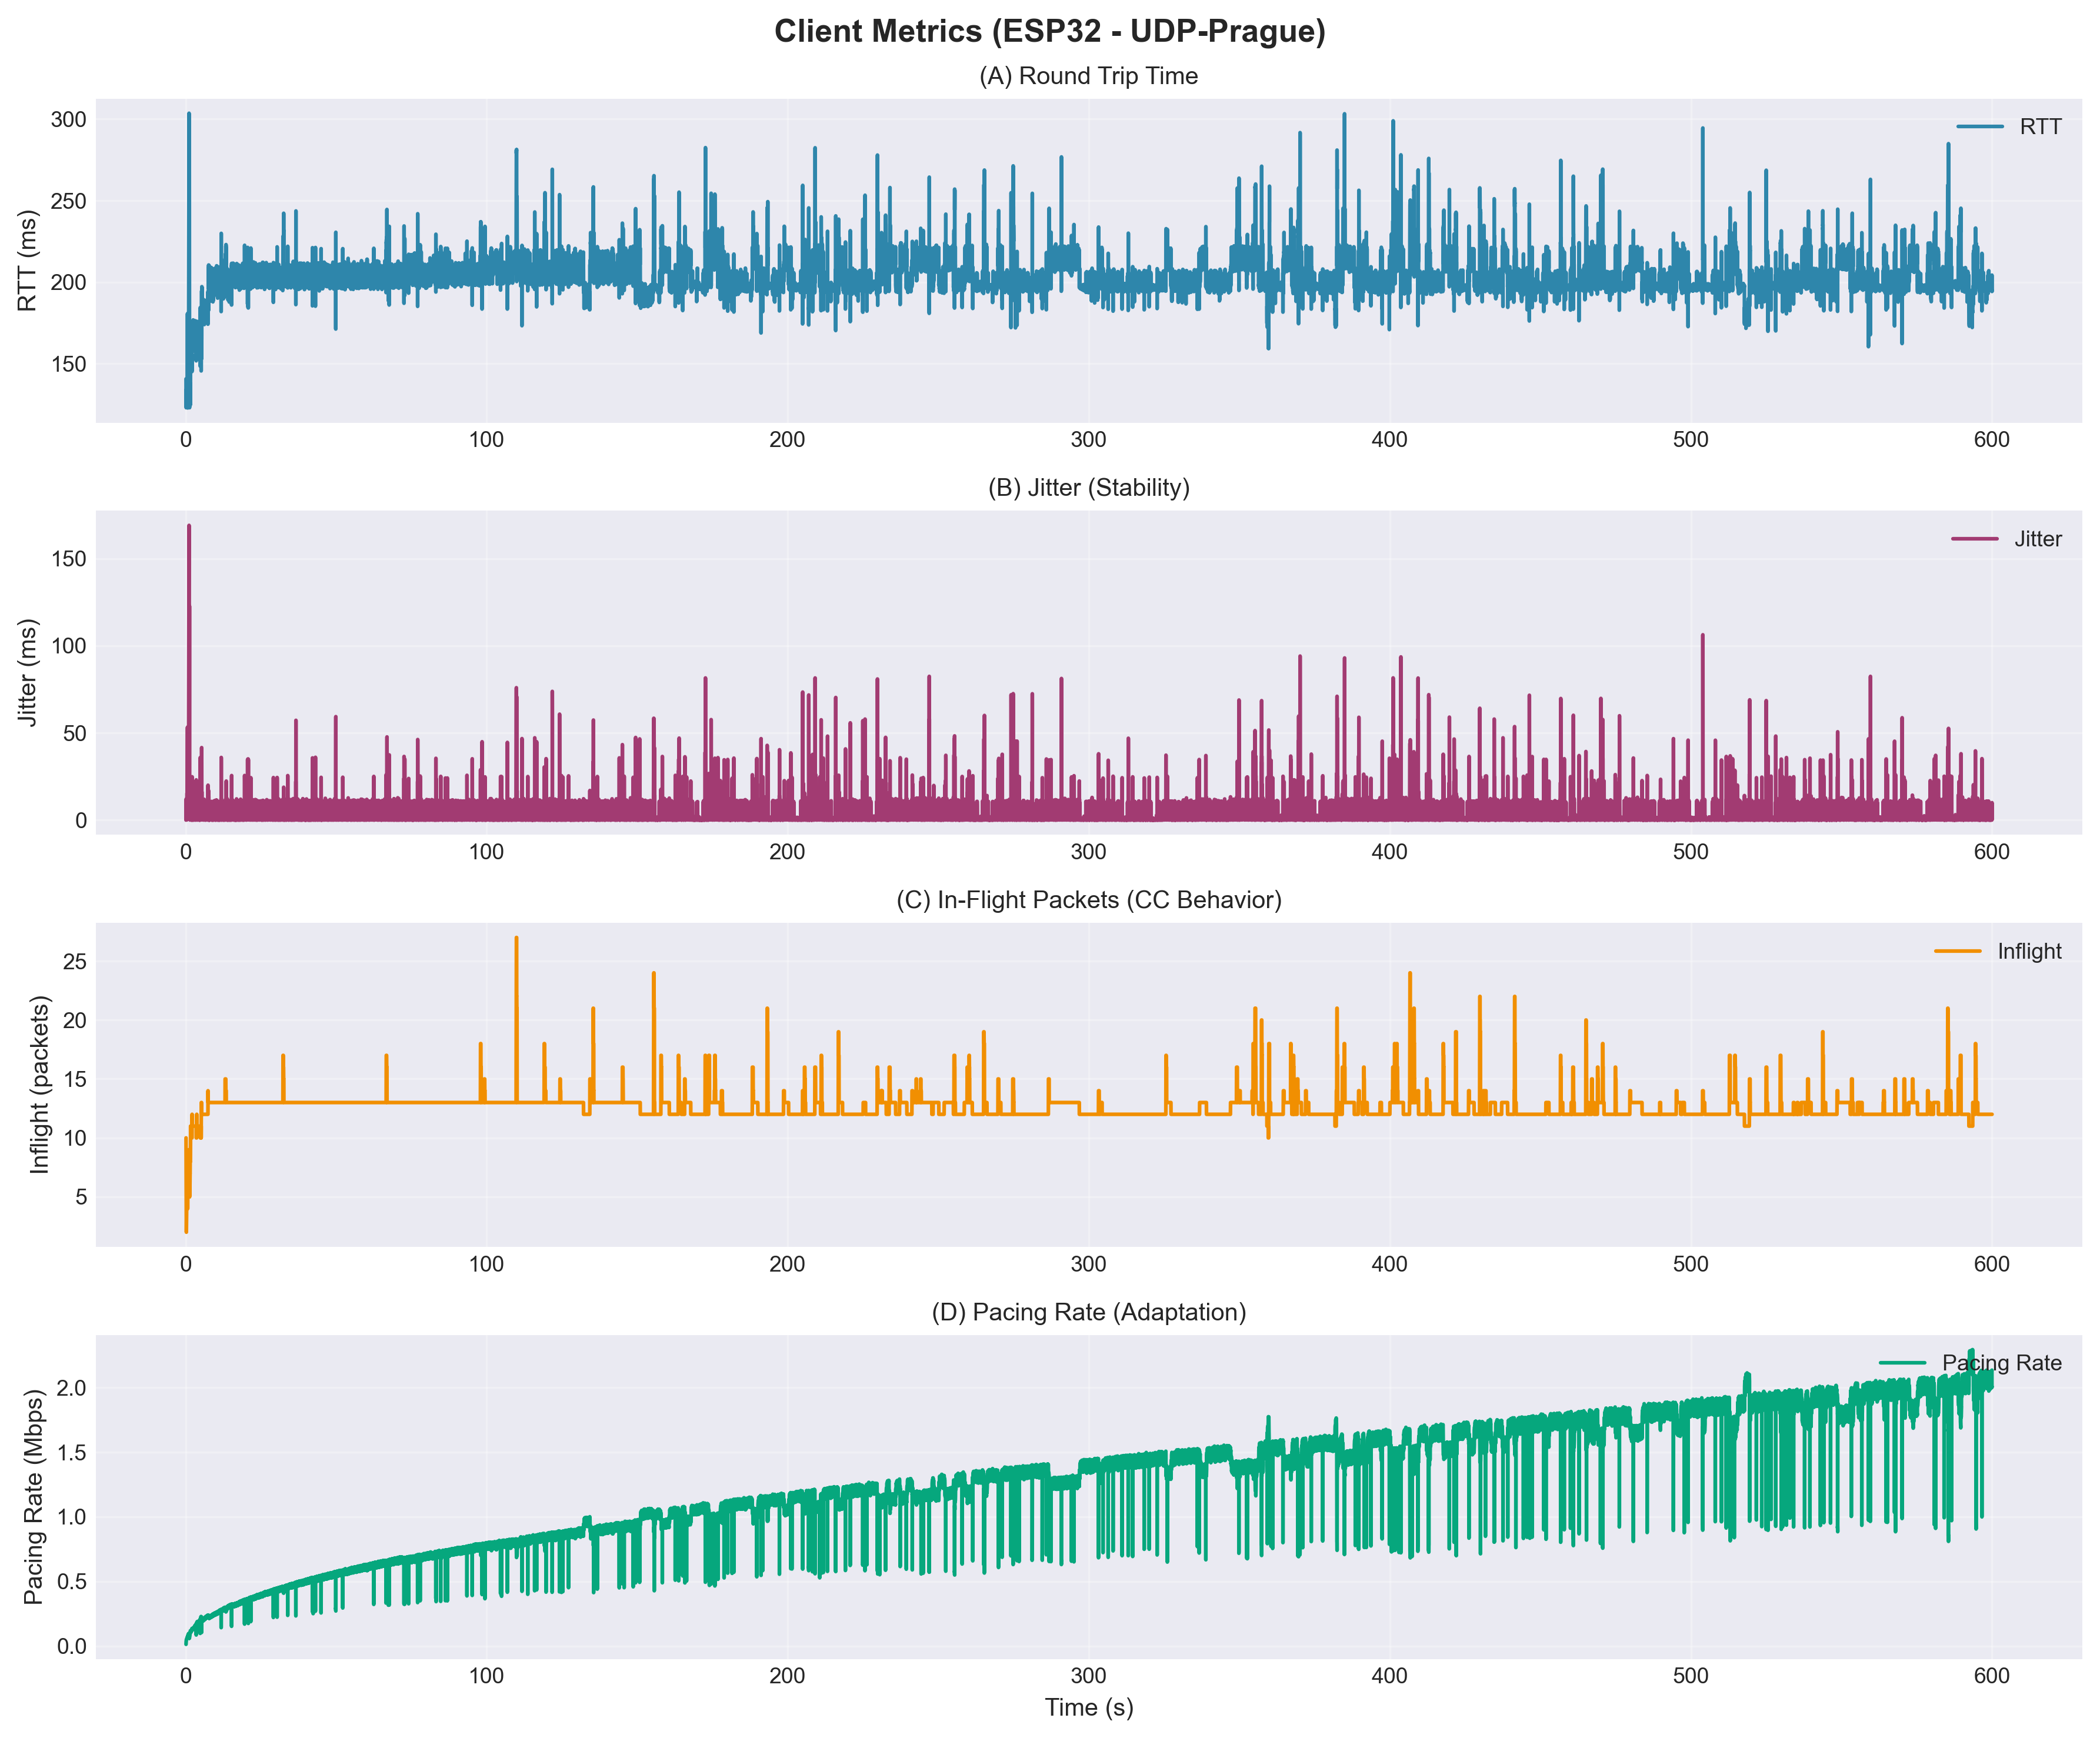

✓ Saved: /Users/juscelioreis/Documents/code/master-l4s-iot/esp32-udp-prague/experiments/t06-ecn-sender-ect1-prague-dualpi2-ecn2/prague_academic_high_load_node1_ccprague_qdiscdualpi2_ecn1_rtt_cdf.png


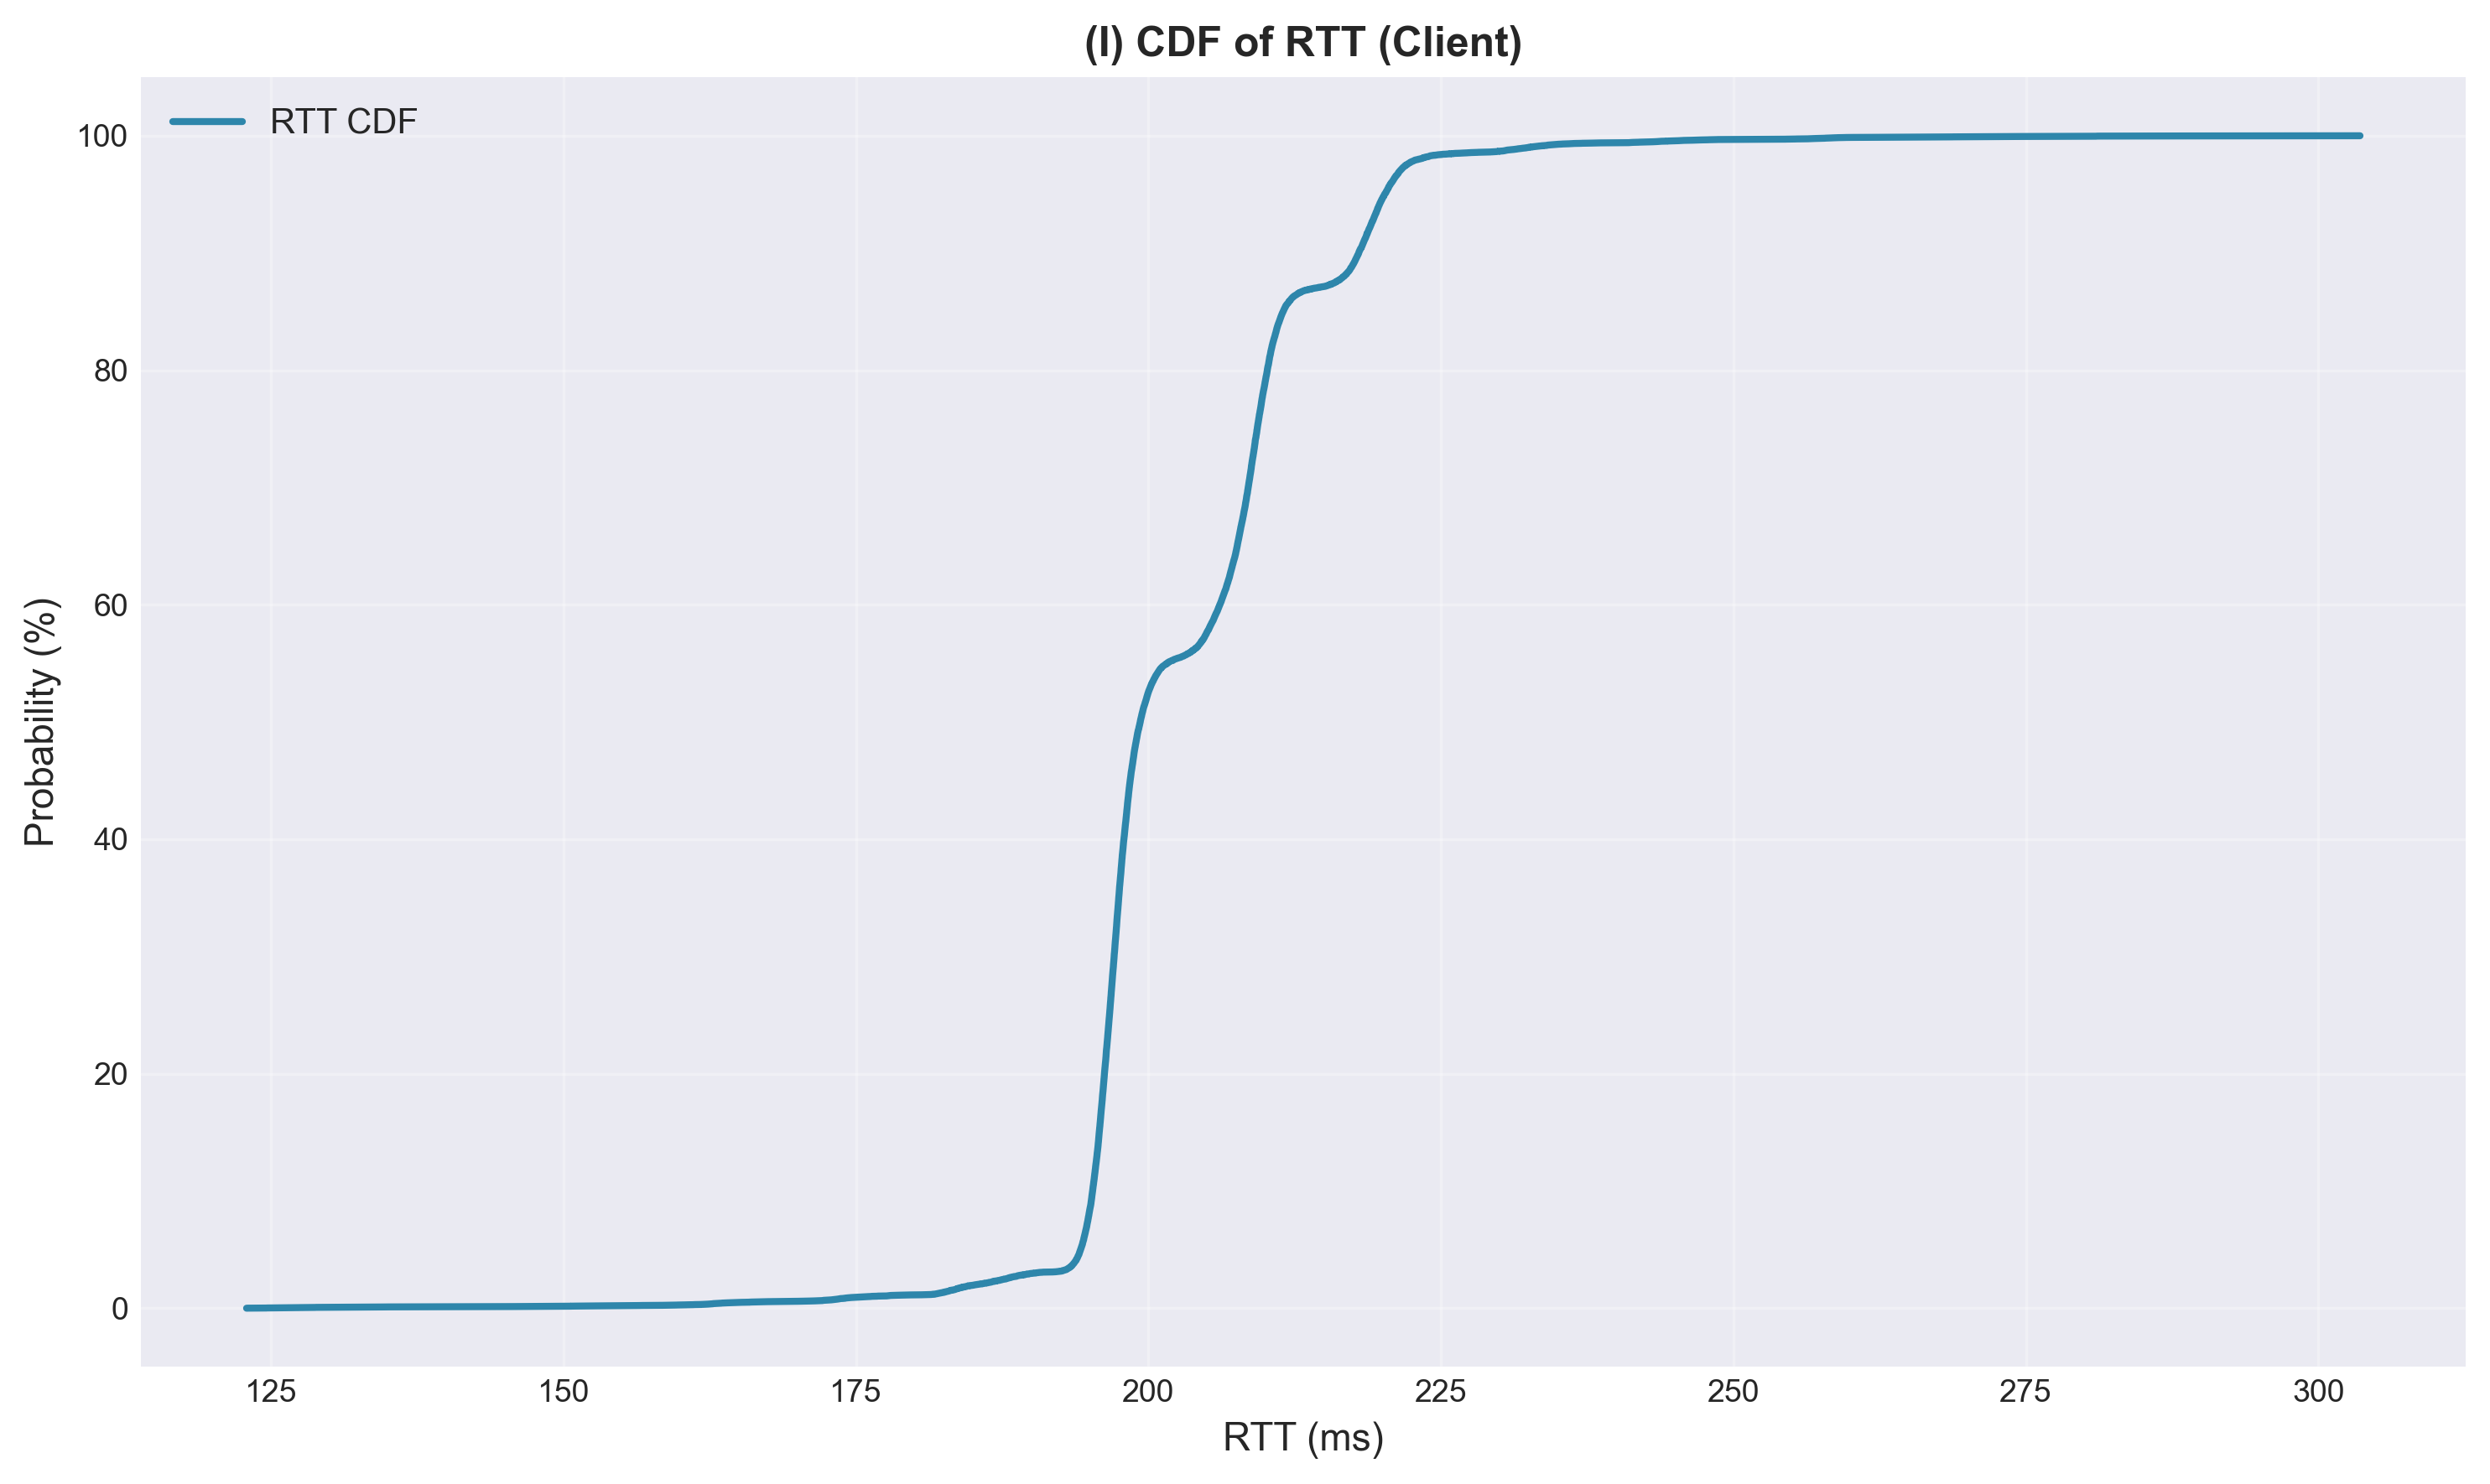

In [69]:
# Generate output filename from metadata
def build_output_name(metadata):
    parts = ['prague_academic']
    
    scenario = metadata.get('Test Scenario', '').lower().replace(' ', '_')
    if scenario:
        parts.append(scenario)
    
    node = metadata.get('IoT Node ID', '')
    if node:
        digits = re.findall(r'\d+', node)
        if digits:
            parts.append(f'node{digits[0]}')
    
    cc = metadata.get('Gateway CC Algorithm', '').lower().replace(' ', '_')
    if cc:
        parts.append(f'cc{cc}')
    
    qdisc = metadata.get('Gateway Qdisc', '').lower().replace(' ', '_')
    if qdisc:
        parts.append(f'qdisc{qdisc}')
    
    ecn = metadata.get('ECN', '')
    if ecn:
        parts.append(f'ecn{ecn}')

    return '_'.join(parts)

base_name = build_output_name(metadata)
print(f"Output name: {base_name}")

# Plot and save client metrics
if not df_client.empty:
    fig = plot_client_metrics(df_client, metadata)
    if fig:
        fname = OUTPUT_DIR / f"{base_name}_client_metrics.png"
        fig.savefig(fname, dpi=300, bbox_inches='tight')
        print(f"✓ Saved: {fname}")
        plt.show()

# Plot and save server metrics
if not df_server.empty:
    fig = plot_server_metrics(df_server, metadata)
    if fig:
        fname = OUTPUT_DIR / f"{base_name}_server_metrics.png"
        fig.savefig(fname, dpi=300, bbox_inches='tight')
        print(f"✓ Saved: {fname}")
        plt.show()

# Plot and save CDF of RTT
if not df_client.empty:
    fig = plot_cdf_rtt(df_client)
    if fig:
        fname = OUTPUT_DIR / f"{base_name}_rtt_cdf.png"
        fig.savefig(fname, dpi=300, bbox_inches='tight')
        print(f"✓ Saved: {fname}")
        plt.show()

## Export CSV

In [70]:
# Export raw data
if not df_client.empty:
    fname_csv = OUTPUT_DIR / f"{base_name}_client.csv"
    df_client.to_csv(fname_csv, index=False)
    print(f"✓ Saved: {fname_csv}")

if not df_server.empty:
    fname_csv = OUTPUT_DIR / f"{base_name}_server.csv"
    df_server.to_csv(fname_csv, index=False)
    print(f"✓ Saved: {fname_csv}")

# Summary statistics
if not df_client.empty or not df_server.empty:
    summary = {}
    if not df_client.empty:
        summary.update({
            'client_samples': len(df_client),
            'client_duration_s': df_client['t_client_s'].max() - df_client['t_client_s'].min(),
            'rtt_mean_ms': df_client['rtt_ms'].mean(),
            'rtt_p50_ms': df_client['rtt_ms'].median(),
            'rtt_p95_ms': df_client['rtt_ms'].quantile(0.95),
            'rtt_p99_ms': df_client['rtt_ms'].quantile(0.99),
            'jitter_mean_ms': df_client['jitter_ms'].mean(),
            'inflight_mean': df_client['inflight'].mean(),
            'pacing_rate_mean_mbps': df_client['pacing_rate_mbps'].mean(),
        })
    if not df_server.empty:
        summary.update({
            'server_samples': len(df_server),
            'server_duration_s': df_server['time_sec'].max() - df_server['time_sec'].min(),
            'rx_throughput_mean_bytes_s': df_server['rcvd_rate_bytes_s'].mean(),
            'rx_throughput_min_bytes_s': df_server['rcvd_rate_bytes_s'].min(),
            'rx_throughput_max_bytes_s': df_server['rcvd_rate_bytes_s'].max(),
            'ce_mark_rate_mean_percent': df_server['ce_rate_percent'].mean(),
            'loss_rate_mean_percent': df_server['loss_rate_percent'].mean(),
        })
    
    # Add transmission analysis stats
    if 'transmission_stats' in globals():
        summary.update(transmission_stats)
    
    summary_df = pd.DataFrame([summary])
    fname_summary = OUTPUT_DIR / f"{base_name}_summary.csv"
    summary_df.to_csv(fname_summary, index=False)
    print(f"✓ Saved: {fname_summary}")
    print(f"\n📊 Summary Statistics:")
    print(summary_df.T)


✓ Saved: /Users/juscelioreis/Documents/code/master-l4s-iot/esp32-udp-prague/experiments/t06-ecn-sender-ect1-prague-dualpi2-ecn2/prague_academic_high_load_node1_ccprague_qdiscdualpi2_ecn1_client.csv
✓ Saved: /Users/juscelioreis/Documents/code/master-l4s-iot/esp32-udp-prague/experiments/t06-ecn-sender-ect1-prague-dualpi2-ecn2/prague_academic_high_load_node1_ccprague_qdiscdualpi2_ecn1_summary.csv

📊 Summary Statistics:
                                  0
client_samples         37486.000000
client_duration_s        599.858000
rtt_mean_ms              203.312586
rtt_p50_ms               199.298000
rtt_p95_ms               220.182750
rtt_p99_ms               232.499300
jitter_mean_ms             4.432314
inflight_mean             12.581604
pacing_rate_mean_mbps      1.280852
